### 2층 신경망을 활용해서 mnist 이미지 데이터 학습    

In [4]:
import sys, os
sys.path.append("C:/Users/KimDongyoung/Desktop/Github/my_git/mygit/DEEPLEARNING/퍼셉트론")

import numpy as np
import mnist as mnist
from ch05.two_layer_net import TwoLayerNet
import matplotlib.pyplot as plt

In [5]:
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True, one_hot_label=True) # one_hot_label=True이면 타겟 벡터가 원핫인코딩으로 변환됨

# TwoLayerNet은 은닉 층이 하나인 신경망을 구현한 계층
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)                       # 784=28*28, 50=hidden layer의 노드 수, 10=output layer의 노드 수


In [18]:
iters_num = 12000 # 반복 횟수
train_size = x_train.shape[0] # 데이터 수: 60000
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []
epoch_list = []


# 한 에폭당 반복하는 횟수 
iter_per_epoch = max(train_size / batch_size, 1) # 600번 (60000/100=600)

# 총 에포크 개수 계산
total_epochs = iters_num // iter_per_epoch

print(f"총 에포크 개수: {total_epochs}")

for i in range(iters_num): # 1 에폭당 반복 횟수만큼 반복
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 기울기 계산
    #grad = network.numerical_gradient(x_batch, t_batch) # 수치 미분 방식
    grad = network.gradient(x_batch, t_batch) # 오차역전파법 방식
    
    # 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key] # 가중치 매개변수 갱신 방법으로 확률적 경사 하강법을 사용함
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    # 매 에포크마다의 손실 함수 값과 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        epoch_list.append(i // iter_per_epoch + 1)
        print(f"Epoch {i // iter_per_epoch + 1}: Train Accuracy = {train_acc}, Test Accuracy = {test_acc}")
        
        

총 에포크 개수: 20.0
Epoch 1.0: Train Accuracy = 0.9992833333333333, Test Accuracy = 0.9726
Epoch 2.0: Train Accuracy = 0.9995166666666667, Test Accuracy = 0.9729
Epoch 3.0: Train Accuracy = 0.9995833333333334, Test Accuracy = 0.9731
Epoch 4.0: Train Accuracy = 0.9990833333333333, Test Accuracy = 0.972
Epoch 5.0: Train Accuracy = 0.99955, Test Accuracy = 0.9733
Epoch 6.0: Train Accuracy = 0.99935, Test Accuracy = 0.9721
Epoch 7.0: Train Accuracy = 0.9997166666666667, Test Accuracy = 0.9733
Epoch 8.0: Train Accuracy = 0.9997, Test Accuracy = 0.9729
Epoch 9.0: Train Accuracy = 0.9997, Test Accuracy = 0.972
Epoch 10.0: Train Accuracy = 0.9996833333333334, Test Accuracy = 0.973
Epoch 11.0: Train Accuracy = 0.9998, Test Accuracy = 0.9739
Epoch 12.0: Train Accuracy = 0.99975, Test Accuracy = 0.9732
Epoch 13.0: Train Accuracy = 0.9997333333333334, Test Accuracy = 0.973
Epoch 14.0: Train Accuracy = 0.9996, Test Accuracy = 0.972
Epoch 15.0: Train Accuracy = 0.99975, Test Accuracy = 0.9731
Epoch 16.0:

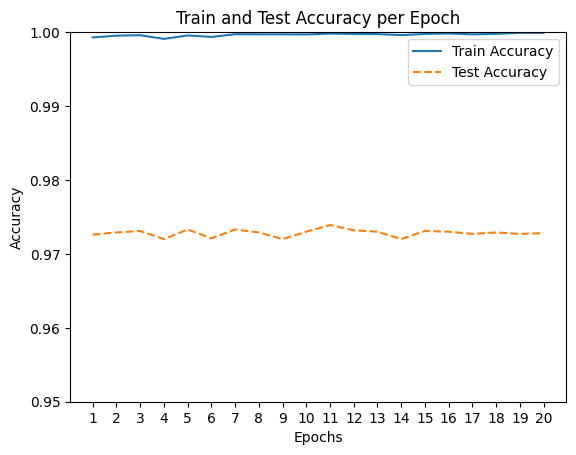

In [31]:
# 그래프 시각화
plt.plot(epoch_list, train_acc_list, label='Train Accuracy')
plt.plot(epoch_list, test_acc_list, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.0)  # y축 범위를 0부터 1 사이로 설정
plt.xticks(epoch_list)
plt.legend()
plt.title('Train and Test Accuracy per Epoch')
plt.show()